In [1]:
# Installation des dépendances nécessaires au projet
import subprocess, sys

packages = [
    "numpy==1.26.4",
    "momentfm --no-deps",
    "transformers==4.40.2",
    "huggingface-hub>=0.34.0,<1.0",
    "chronos-forecasting==1.3.0",
    "tslearn",
    "datasets",
    "einops",
]

for pkg in packages:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "--no-warn-conflicts",           # supprime les conflits de dépendances
         "--disable-pip-version-check",   # supprime le warning version pip
        ] + pkg.split(),
        check=False,
        stderr=subprocess.DEVNULL        # supprime les WARNING invalid distribution
    )

print("Installation terminée.")

Installation terminée.


# Projet Time Series — Classification LSST

Ce notebook présente notre approche pour le projet de classification de séries temporelles sur le dataset **LSST** (Large Synoptic Survey Telescope).

Deux settings sont explorés :
- **Setting 1** : Adaptation de modèles de fondation (MOMENT, Chronos)
- **Setting 2** : Pré-entraînement sur une tâche de forecasting, puis fine-tuning sur LSST

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd

from tslearn.datasets import UCR_UEA_datasets

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset

from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import lightgbm as lgb

import momentfm
from momentfm import MOMENTPipeline

from chronos import ChronosPipeline

In [3]:
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

In [4]:
# Sélection automatique du device (GPU si disponible, sinon CPU)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 1. Analyse des données

On commence par explorer le dataset LSST : dimensions, distribution des classes et visualisation d'une série.

In [5]:
print(f"Format X_train : {X_train.shape}") # (nb_samples, nb_timestamps, nb_features)

print(f"Nombre de classes : {len(set(y_train))}")

Format X_train : (2459, 36, 6)
Nombre de classes : 14


In [6]:
print(X_train.shape,
y_train.shape,
X_test.shape,
y_train.shape)

(2459, 36, 6) (2459,) (2466, 36, 6) (2459,)


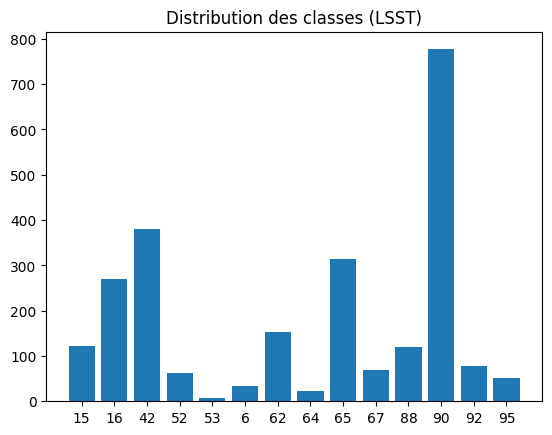

In [7]:
# Distribution des classes
classes, counts = np.unique(y_train, return_counts=True)
plt.bar(classes, counts)
plt.title("Distribution des classes (LSST)")
plt.show()

Les classes sont fortement déséquilibrées. On utilise donc le F1-score macro comme métrique principale, et on pondère la `CrossEntropyLoss` en conséquence.

In [8]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

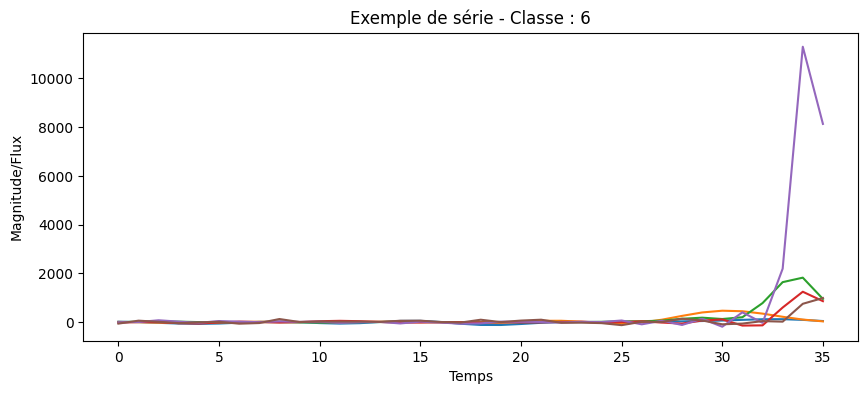

In [9]:
# Visualisation d'une série temporelle
# On affiche la première série (toutes ses features)
plt.figure(figsize=(10, 4))
plt.plot(X_train[0])
plt.title(f"Exemple de série - Classe : {y_train[0]}")
plt.xlabel("Temps")
plt.ylabel("Magnitude/Flux")
plt.show()

## 2. Fonctions utilitaires

Ces fonctions sont partagées par tous les modèles : boucle d'entraînement/évaluation et affichage de la matrice de confusion.

In [10]:
def train_and_eval_epoch(model, classifier, dataloader, optimizer, criterion, freeze_encoder, is_training=True):
    target_model = model.model if hasattr(model, 'model') and not hasattr(model, 'train') else model
    
    if is_training:
        if hasattr(target_model, 'train'): target_model.train() if not freeze_encoder else target_model.eval()
        classifier.train()
    else:
        if hasattr(target_model, 'eval'): target_model.eval()
        classifier.eval()

    total_loss, all_preds, all_targets = 0, [], []
    grad_env = torch.set_grad_enabled(is_training)
    
    with grad_env:
        for batch_X, batch_y in dataloader:
            batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
            if batch_X.shape[1] == 36: batch_X = batch_X.transpose(1, 2)
            if is_training: optimizer.zero_grad()
            
            if "ChronosPipeline" in str(type(model)): # Cas CHRONOS
                B, C, T = batch_X.shape
                x_flat = batch_X.reshape(B * C, T).cpu() 
                
                outputs_tuple = model.embed(x_flat) 
                embeddings = outputs_tuple[0] # On prend uniquement les embeddings
                
                pooled = embeddings.mean(dim=1).to(DEVICE) 
                features = pooled.view(B, C, -1).mean(dim=1)
                logits = classifier(features)
                
            elif hasattr(model, 'embed'): # Cas MOMENT
                batch_X_pad = F.pad(batch_X, (0, 512 - batch_X.shape[-1]))
                
                if is_training and not freeze_encoder:
                    batch_X_pad.requires_grad_(True) 
                    
                outputs = model.embed(x_enc=batch_X_pad)
                embeddings = outputs.embeddings if hasattr(outputs, 'embeddings') else outputs
                features = embeddings.mean(dim=1) if embeddings.dim() == 3 else embeddings
                logits = classifier(features)
            else: # Cas BASELINES
                logits = model(batch_X.transpose(1, 2))
            
            loss = criterion(logits, batch_y)
            if is_training:
                loss.backward()
                optimizer.step()
            
            total_loss += loss.item()
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    acc = accuracy_score(all_targets, all_preds)
    return avg_loss, acc, f1

In [32]:
def plot_confusion_matrix(model, classifier, dataloader, le, title="Matrice de Confusion"):
    target_model = model.model if hasattr(model, 'model') and not hasattr(model, 'train') else model
    
    target_model.eval()
    classifier.eval()

    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
            if batch_X.shape[1] == 36: batch_X = batch_X.transpose(1, 2)

            if "ChronosPipeline" in str(type(model)):
                B, C, T = batch_X.shape
                x_flat = batch_X.reshape(B * C, T).cpu()
                outputs_tuple = model.embed(x_flat)
                embeddings = outputs_tuple[0]
                pooled = embeddings.mean(dim=1).to(DEVICE)
                features = pooled.view(B, C, -1).mean(dim=1)
                logits = classifier(features)

            elif isinstance(model, MOMENTclassifier):  
                logits = model(batch_X)

            elif hasattr(model, 'embed'):
                batch_X_pad = F.pad(batch_X, (0, 512 - batch_X.shape[-1]))
                outputs = model.embed(x_enc=batch_X_pad)
                embeddings = outputs.embeddings if hasattr(outputs, 'embeddings') else outputs
                features = embeddings.mean(dim=1) if embeddings.dim() == 3 else embeddings
                logits = classifier(features)

            else:  # Cas BASELINES (CNN, ORACLE)
                logits = model(batch_X.transpose(1, 2))

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())

    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(title)
    plt.ylabel('Vraie classe')
    plt.xlabel('Classe prédite')
    plt.tight_layout()
    plt.show()

In [12]:
BATCH_SIZE = 32

# Encodage des labels de 0 à C-1 (C le nb de classes)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
num_classes = len(le.classes_)

# Les données sont (N, 36, 6), PyTorch Conv1D attend (N, 6, 36)
X_train_t = torch.tensor(X_train, dtype=torch.float32).transpose(1, 2).to(DEVICE)
y_train_t = torch.tensor(y_train_encoded, dtype=torch.long).to(DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32).transpose(1, 2).to(DEVICE)
y_test_t = torch.tensor(y_test_encoded, dtype=torch.long).to(DEVICE)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE)



## 3. Baselines

Deux baselines sont évaluées pour établir un point de référence sans pré-entraînement.

### 3.1 CNN 1D

Un CNN 1D simple appliqué directement sur les séries temporelles multiVariées.

In [13]:
class TimeSeriesCNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # On s'attend à recevoir (B, T, C), donc on transpose pour Conv1d (B, C, T)
            nn.Conv1d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), 
            nn.GELU(),
            
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), 
            nn.GELU(),

            nn.AdaptiveAvgPool1d(8),
            
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), 
            nn.GELU(),

            nn.AdaptiveAvgPool1d(1)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x arrive en (B, T, C) via la fonction universelle
        x = x.transpose(1, 2) # Devient (B, C, T) pour les Conv1d
        x = self.features(x)
        return self.classifier(x)

In [14]:
def run_cnn_experiment(epochs, lr, weights_tensor):
    print(f"Initialisation de la Baseline CNN...")
    
    # Initialisation du modèle
    # in_channels = 6 (nb de filtres LSST)
    model = TimeSeriesCNN(in_channels=6, num_classes=num_classes).to(DEVICE)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)

    history = {'train_f1': [], 'test_f1': [], 'train_loss': [], 'test_loss': []}

    for epoch in range(epochs): #
        # On utilise la fonction universelle (classifier = nn.Identity car déjà inclus)
        tr_loss, tr_acc, tr_f1 = train_and_eval_epoch(
            model, nn.Identity(), train_loader, optimizer, criterion, False, is_training=True
        )
        ts_loss, ts_acc, ts_f1 = train_and_eval_epoch(
            model, nn.Identity(), test_loader, optimizer, criterion, False, is_training=False
        )
        
        # Sauvegarde de l'historique
        history['train_f1'].append(tr_f1)
        history['test_f1'].append(ts_f1)
        history['train_loss'].append(tr_loss)
        history['test_loss'].append(ts_loss)
        
        if (epoch + 1) % 5 == 0:
            print(f"CNN Epoch [{epoch+1}/{epochs}] | Train F1: {tr_f1:.4f} | Test F1: {ts_f1:.4f} | Loss: {tr_loss:.4f}")

    return model, history

In [15]:
cnn_model, cnn_history = run_cnn_experiment(
    epochs=100, 
    lr=0.001, 
    weights_tensor=weights_tensor
)

Initialisation de la Baseline CNN...
CNN Epoch [5/100] | Train F1: 0.3262 | Test F1: 0.2336 | Loss: 1.8402
CNN Epoch [10/100] | Train F1: 0.3835 | Test F1: 0.3061 | Loss: 1.6011
CNN Epoch [15/100] | Train F1: 0.3899 | Test F1: 0.3095 | Loss: 1.6224
CNN Epoch [20/100] | Train F1: 0.4188 | Test F1: 0.2484 | Loss: 1.5199
CNN Epoch [25/100] | Train F1: 0.4716 | Test F1: 0.2934 | Loss: 1.2982
CNN Epoch [30/100] | Train F1: 0.4670 | Test F1: 0.3276 | Loss: 1.3227
CNN Epoch [35/100] | Train F1: 0.4706 | Test F1: 0.3428 | Loss: 1.2550
CNN Epoch [40/100] | Train F1: 0.5086 | Test F1: 0.4116 | Loss: 1.1863
CNN Epoch [45/100] | Train F1: 0.4985 | Test F1: 0.3024 | Loss: 1.1954
CNN Epoch [50/100] | Train F1: 0.5370 | Test F1: 0.3140 | Loss: 1.1038
CNN Epoch [55/100] | Train F1: 0.4770 | Test F1: 0.3468 | Loss: 1.3180
CNN Epoch [60/100] | Train F1: 0.5538 | Test F1: 0.3706 | Loss: 1.0309
CNN Epoch [65/100] | Train F1: 0.5416 | Test F1: 0.3327 | Loss: 1.0388
CNN Epoch [70/100] | Train F1: 0.5583 | T

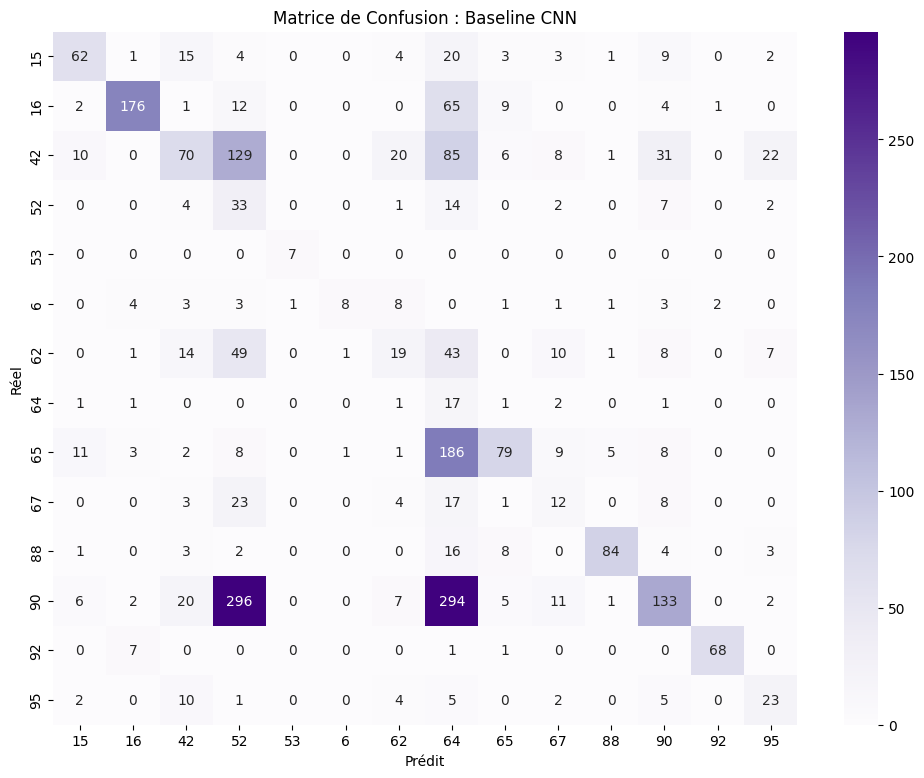

In [16]:
plot_confusion_matrix(
    cnn_model, 
    nn.Identity(), 
    test_loader, 
    le, 
    title="Matrice de Confusion : Baseline CNN")

### 3.2 ORACLE (GRU)

Modèle GRU entraîné directement sur LSST. Sert de référence forte sans pré-entraînement.

In [17]:
class ORACLEModel(nn.Module):
    def __init__(self, n_channels=6, hidden_dim=128, num_classes=14, num_layers=2):
        super(ORACLEModel, self).__init__()

        self.gru = nn.GRU(
            input_size=n_channels, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True, 
            bidirectional=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        # 2 * hidden_dim car bidirectionnel
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x shape: [Batch, Time=36, Channels=6]
        # hn: [num_layers * 2, Batch, hidden_dim]
        _, hn = self.gru(x)
        # On concatène le dernier état caché des deux directions (avant et arrière)
        out = torch.cat((hn[-2,:,:], hn[-1,:,:]), dim=1)
        return self.classifier(out)

In [18]:
def run_oracle_experiment(epochs, lr):
    model = ORACLEModel(n_channels=6, num_classes=num_classes).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    
    history = {'train_loss': [], 'test_loss': [], 'train_f1': [], 'test_f1': []}
    
    for epoch in range(epochs): #
        tr_loss, tr_acc, tr_f1 = train_and_eval_epoch(model, nn.Identity(), train_loader, optimizer, criterion, False, is_training=True)
        ts_loss, ts_acc, ts_f1 = train_and_eval_epoch(model, nn.Identity(), test_loader, optimizer, criterion, False, is_training=False)
        
        history['train_f1'].append(tr_f1)
        history['test_f1'].append(ts_f1)
        history['train_loss'].append(tr_loss)
        history['test_loss'].append(ts_loss)
        
        if (epoch+1)%5 == 0 :
            # Affichage identique pour comparer
            print(f"ORACLE Epoch [{epoch+1}/{epochs}] | Train F1: {tr_f1:.4f} | Test F1: {ts_f1:.4f} | Loss: {tr_loss:.4f}")
    
    return model, history

In [19]:
oracle_model, oracle_hist = run_oracle_experiment(epochs=100, lr=1e-3)

ORACLE Epoch [5/100] | Train F1: 0.5592 | Test F1: 0.4005 | Loss: 0.8725
ORACLE Epoch [10/100] | Train F1: 0.7990 | Test F1: 0.5039 | Loss: 0.3426
ORACLE Epoch [15/100] | Train F1: 0.9278 | Test F1: 0.5290 | Loss: 0.1210
ORACLE Epoch [20/100] | Train F1: 0.9332 | Test F1: 0.4796 | Loss: 0.1104
ORACLE Epoch [25/100] | Train F1: 0.9903 | Test F1: 0.5308 | Loss: 0.0207
ORACLE Epoch [30/100] | Train F1: 0.9994 | Test F1: 0.5455 | Loss: 0.0043
ORACLE Epoch [35/100] | Train F1: 1.0000 | Test F1: 0.5363 | Loss: 0.0015
ORACLE Epoch [40/100] | Train F1: 1.0000 | Test F1: 0.5407 | Loss: 0.0010
ORACLE Epoch [45/100] | Train F1: 1.0000 | Test F1: 0.5327 | Loss: 0.0006
ORACLE Epoch [50/100] | Train F1: 1.0000 | Test F1: 0.5377 | Loss: 0.0005
ORACLE Epoch [55/100] | Train F1: 0.8633 | Test F1: 0.4998 | Loss: 0.2320
ORACLE Epoch [60/100] | Train F1: 0.9984 | Test F1: 0.5112 | Loss: 0.0141
ORACLE Epoch [65/100] | Train F1: 1.0000 | Test F1: 0.5178 | Loss: 0.0042
ORACLE Epoch [70/100] | Train F1: 1.000

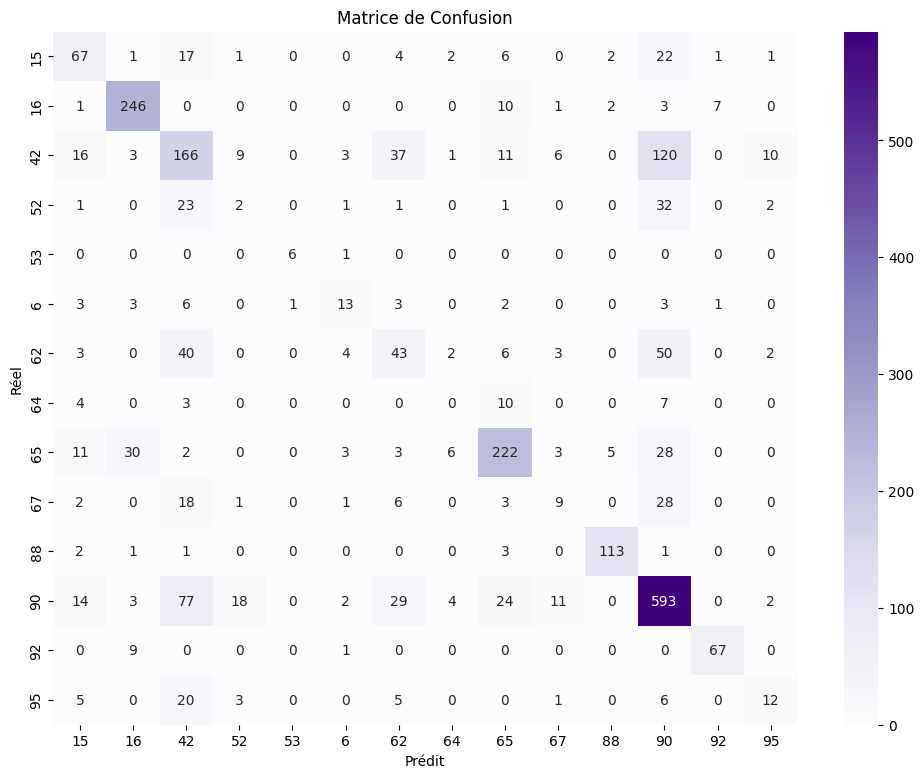

In [20]:
plot_confusion_matrix(oracle_model, nn.Identity(), test_loader, le)

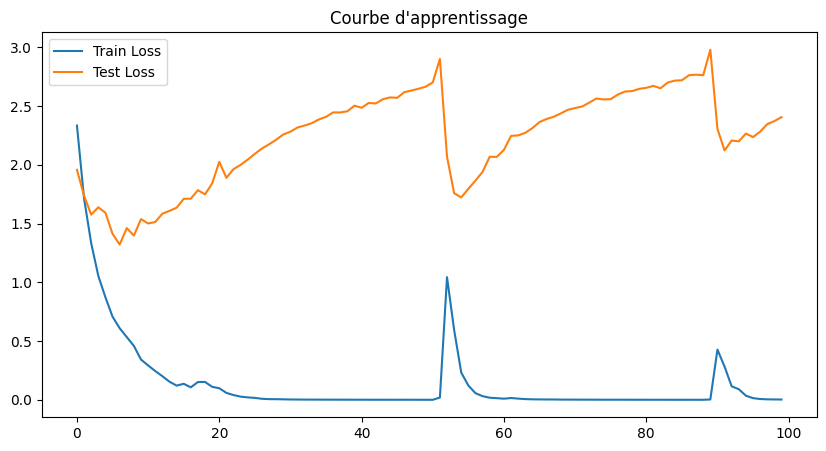

In [21]:
# quick verification of overfitting
plt.figure(figsize=(10, 5))
plt.plot(oracle_hist['train_loss'], label='Train Loss')
plt.plot(oracle_hist['test_loss'], label='Test Loss')
plt.title('Courbe d\'apprentissage')
plt.legend()
plt.show()

Malgré un fort surapprentissage sur le train, l'ORACLE GRU obtient le meilleur F1 test parmi les baselines.

### 3.3 LightGBM

Baseline non-neuronale : les séries sont aplaties et passées à un classifieur gradient boosting.

In [22]:
def run_lgbm_experiment(X_train, y_train, X_test, y_test, num_classes):
    print("Préparation des données pour LightGBM (Aplatissement)...")
    
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)

    lgb_train = lgb.Dataset(X_train_flat, label=y_train)
    lgb_eval = lgb.Dataset(X_test_flat, label=y_test, reference=lgb_train)

    params = {
        'objective': 'multiclass',
        'num_class': num_classes,
        'metric': 'multi_logloss',
        'boosting_type': 'gbdt',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'feature_fraction': 0.8,
        'verbose': -1,
        'random_state': 42
    }

    print("Début de l'entraînement LightGBM...")
    evals_result = {}
    
    gbm = lgb.train(
        params, 
        lgb_train, 
        num_boost_round=150, 
        valid_sets=[lgb_train, lgb_eval],
        valid_names=['train', 'eval'],
        callbacks=[lgb.record_evaluation(evals_result)]
    )

    y_pred_prob = gbm.predict(X_test_flat)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    final_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    final_acc = accuracy_score(y_test, y_pred)
    
    history = {
        'train_loss': evals_result['train']['multi_logloss'],
        'test_loss': evals_result['eval']['multi_logloss'],
        'final_f1': final_f1,
        'final_acc': final_acc
    }

    print(f"LightGBM Terminé | Test F1: {final_f1:.4f} | Test Acc: {final_acc:.4f}")
    return gbm, history

In [23]:
def plot_lgbm_confusion_matrix(model, X_test, y_test, le, title="Matrice de Confusion : LightGBM"):
    X_test_flat = X_test.reshape(X_test.shape[0], -1)
    
    y_pred_prob = model.predict(X_test_flat)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 9))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Purples')
    plt.xlabel('Prédit')
    plt.ylabel('Réel')
    plt.title(title)
    plt.show()

Préparation des données pour LightGBM (Aplatissement)...
Début de l'entraînement LightGBM...
LightGBM Terminé | Test F1: 0.3338 | Test Acc: 0.5474


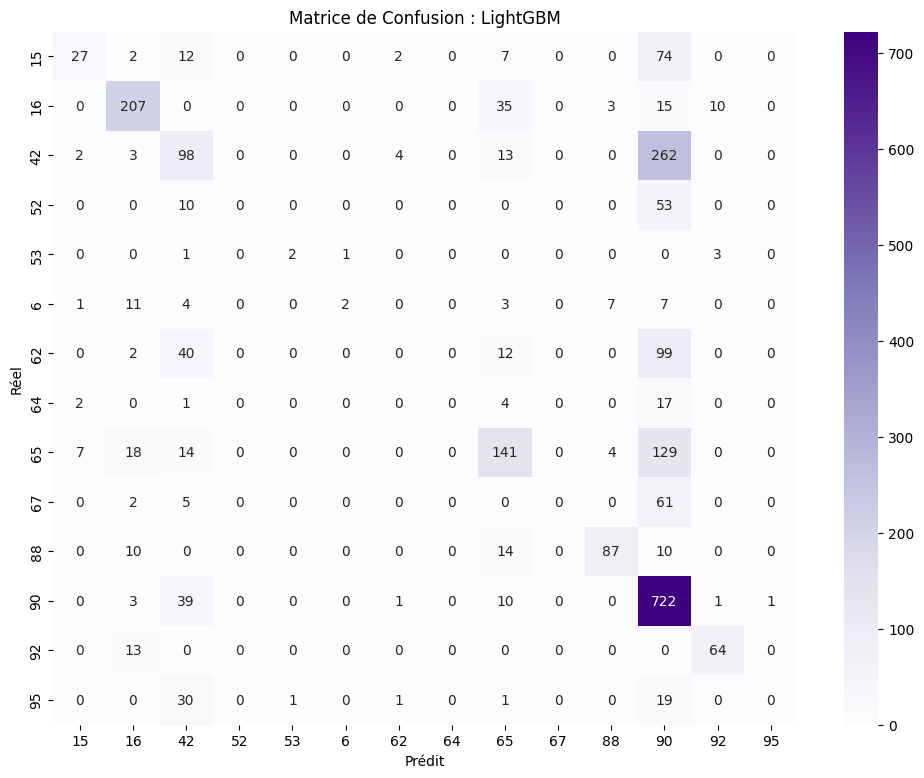

In [24]:
lgbm_model, lgbm_history = run_lgbm_experiment(X_train, y_train_encoded, X_test, y_test_encoded, num_classes)
plot_lgbm_confusion_matrix(lgbm_model, X_test, y_test_encoded, le)

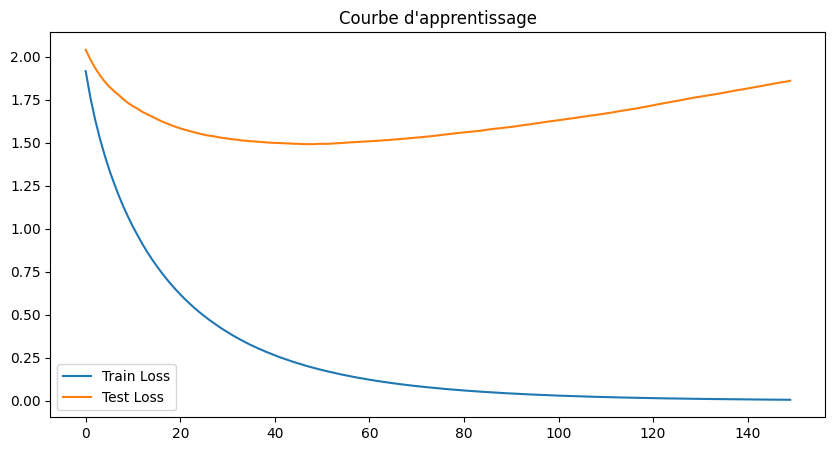

In [25]:
# quick verification of overfitting
plt.figure(figsize=(10, 5))
plt.plot(lgbm_history['train_loss'], label='Train Loss')
plt.plot(lgbm_history['test_loss'], label='Test Loss')
plt.title('Courbe d\'apprentissage')
plt.legend()
plt.show()

## 4. Setting 1 — Adaptation de modèles de fondation

On adapte deux modèles pré-entraînés sur des tâches de séries temporelles : **MOMENT** et **Chronos**.

Une tête de classification complexe (`ComplexClassificationHead`) est ajoutée au-dessus de l'encodeur.

In [26]:
class ComplexClassificationHead(nn.Module):
    """
    Tête de classification complexe (identique à project.ipynb) :
      - LayerNorm d'entrée
      - Attention Squeeze-and-Excitation par canal
      - Projection + bloc résiduel (Linear → BN → GELU → Dropout)
      - Réduction intermédiaire + sortie finale
    """
    def __init__(self, in_dim, num_classes, hidden_dim=512, dropout=0.4):
        super().__init__()
        self.norm_in = nn.LayerNorm(in_dim)
        self.se = nn.Sequential(
            nn.Linear(in_dim, max(in_dim // 4, 1)),
            nn.ReLU(),
            nn.Linear(max(in_dim // 4, 1), in_dim),
            nn.Sigmoid(),
        )
        self.proj  = nn.Linear(in_dim, hidden_dim)
        self.norm1 = nn.BatchNorm1d(hidden_dim)
        self.res_block = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
        )
        self.act  = nn.GELU()
        self.drop = nn.Dropout(dropout)
        self.mid  = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
        )
        self.out = nn.Linear(hidden_dim // 2, num_classes)

    def forward(self, x):
        x = self.norm_in(x)
        x = x * self.se(x)
        h = self.act(self.norm1(self.proj(x)))
        h = self.act(h + self.res_block(h))
        h = self.drop(h)
        h = self.mid(h)
        return self.out(h)


### 4.1 MOMENT

MOMENT est un modèle de fondation pré-entraîné sur des séries temporelles. On compare deux modes :
- **Baseline** : logits natifs du modèle
- **Head** : tête de classification personnalisée sur les embeddings

In [27]:
class MOMENTclassifier(nn.Module):
    """
    Classifieur MOMENT — identique à project.ipynb.
    Modes :
      - Baseline : logits natifs du modèle pré-entraîné (task_name='classification').
      - Head     : ComplexClassificationHead sur embeddings avg+max pooling.
    """
    def __init__(
        self,
        num_channels,
        num_classes,
        pretrained_model_name="AutonLab/MOMENT-1-small",
        mode="Baseline",
    ):
        super().__init__()
        self.mode = mode

        self.moment = MOMENTPipeline.from_pretrained(
            pretrained_model_name,
            model_kwargs={
                "task_name": "classification",
                "num_class": num_classes,
                "n_channels": num_channels,
                "freeze_encoder": True,
                "enable_gradient_checkpointing": False,
            },
        )
        self.moment.init()

        self.head = nn.Sequential(
            nn.LazyLinear(512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        output = self.moment(x_enc=x)

        if self.mode == "Baseline":
            return output.logits

        embeddings = output.embeddings          # [B, n_patches, D]
        avg_pool = torch.mean(embeddings, dim=1)
        max_pool = torch.max(embeddings, dim=1).values
        combined = torch.cat((avg_pool, max_pool), dim=1)
        return self.head(combined)

    def freeze_encoder(self):
        for param in self.moment.encoder.parameters():
            param.requires_grad = False

    def unfreeze_last_n_layers(self, n=2):
        """Dégèle les n dernières couches — gère T5Stack et PyTorch standard."""
        enc = self.moment.encoder
        if hasattr(enc, 'transformer_encoder') and hasattr(enc.transformer_encoder, 'layers'):
            layers = list(enc.transformer_encoder.layers)
        elif hasattr(enc, 'encoder') and hasattr(enc.encoder, 'block'):
            layers = list(enc.encoder.block)      # T5Stack encapsulé
        elif hasattr(enc, 'block'):
            layers = list(enc.block)              # T5Stack direct
        else:
            for p in list(enc.parameters())[-max(1, len(list(enc.parameters()))//4):]:
                p.requires_grad = True
            return
        for layer in layers[-n:]:
            for param in layer.parameters():
                param.requires_grad = True

    def unfreeze_encoder(self):
        for param in self.moment.encoder.parameters():
            param.requires_grad = True

In [28]:
def train_MOMENT(
    model_baseline,
    model_head,
    train_loader,
    test_loader,
    optimizer_baseline,
    optimizer_head,
    n_epoch=10,
    freeze_baseline=True,
    freeze_head=True,
):
    """
    Entraîne les deux modèles MOMENT (Baseline + Head) — identique à project.ipynb.
    Retourne l'historique complet (loss, acc, F1).
    """
    model_baseline.to(DEVICE)
    model_head.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)

    history = {
        "train_loss_base": [], "train_acc_base": [], "test_acc_base": [], "test_f1_base": [],
        "train_loss_head": [], "train_acc_head": [], "test_acc_head": [], "test_f1_head": [],
    }

    for epoch in range(n_epoch):
        print(f"Epoch {epoch+1}/{n_epoch} RUNNING")
        model_baseline.train()
        model_head.train()

        # Gèle l'encodeur si demandé (mode probing)
        if freeze_baseline:
            model_baseline.moment.encoder.eval()
            for p in model_baseline.moment.encoder.parameters():
                p.requires_grad = False
        if freeze_head:
            model_head.moment.encoder.eval()
            for p in model_head.moment.encoder.parameters():
                p.requires_grad = False

        total_loss_base, total_loss_head = 0.0, 0.0
        preds_base, preds_head, labels_base, labels_head = [], [], [], []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

            # Baseline
            optimizer_baseline.zero_grad()
            out_base = model_baseline(X_batch)
            loss_base = criterion(out_base, y_batch)
            loss_base.backward()
            optimizer_baseline.step()
            total_loss_base += loss_base.item()
            preds_base.extend(out_base.argmax(dim=1).cpu().numpy())
            labels_base.extend(y_batch.cpu().numpy())

            # Head
            optimizer_head.zero_grad()
            out_head = model_head(X_batch)
            loss_head = criterion(out_head, y_batch)
            loss_head.backward()
            optimizer_head.step()
            total_loss_head += loss_head.item()
            preds_head.extend(out_head.argmax(dim=1).cpu().numpy())
            labels_head.extend(y_batch.cpu().numpy())

        train_acc_base = accuracy_score(labels_base, preds_base)
        train_acc_head = accuracy_score(labels_head, preds_head)

        # Évaluation
        model_baseline.eval(); model_head.eval()
        tp_base, tp_head, tl = [], [], []
        with torch.no_grad():
            for X_t, y_t in test_loader:
                X_t, y_t = X_t.to(DEVICE), y_t.to(DEVICE)
                tp_base.extend(model_baseline(X_t).argmax(dim=1).cpu().numpy())
                tp_head.extend(model_head(X_t).argmax(dim=1).cpu().numpy())
                tl.extend(y_t.cpu().numpy())

        test_acc_base = accuracy_score(tl, tp_base)
        test_acc_head = accuracy_score(tl, tp_head)
        test_f1_base  = f1_score(tl, tp_base, average="macro", zero_division=0)
        test_f1_head  = f1_score(tl, tp_head, average="macro", zero_division=0)

        print(f"  Baseline | Loss: {total_loss_base/len(train_loader):.4f} | "
              f"Train Acc: {train_acc_base:.2%} | Test Acc: {test_acc_base:.2%} | F1: {test_f1_base:.4f}")
        print(f"  Head     | Loss: {total_loss_head/len(train_loader):.4f} | "
              f"Train Acc: {train_acc_head:.2%} | Test Acc: {test_acc_head:.2%} | F1: {test_f1_head:.4f}")
        print("-" * 65)

        history["train_loss_base"].append(total_loss_base / len(train_loader))
        history["train_acc_base"].append(train_acc_base)
        history["test_acc_base"].append(test_acc_base)
        history["test_f1_base"].append(test_f1_base)
        history["train_loss_head"].append(total_loss_head / len(train_loader))
        history["train_acc_head"].append(train_acc_head)
        history["test_acc_head"].append(test_acc_head)
        history["test_f1_head"].append(test_f1_head)

    return history


#### Instanciation des modèles MOMENT

In [29]:
num_classes = len(le.classes_)
num_channels = X_train.shape[2]  # 6 pour LSST (après transpose tslearn)

model_baseline = MOMENTclassifier(
    num_channels=num_channels,
    num_classes=num_classes,
    mode="Baseline",
).to(DEVICE)

model_head = MOMENTclassifier(
    num_channels=num_channels,
    num_classes=num_classes,
    mode="Head",
).to(DEVICE)

optimizer_baseline = torch.optim.AdamW(model_baseline.parameters(), lr=1e-4, weight_decay=1e-2)
optimizer_head     = torch.optim.AdamW(model_head.parameters(),     lr=1e-4, weight_decay=1e-2)


/usr/local/lib/python3.12/dist-packages/momentfm/models/moment.py:174: UserWarning: Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.
  warnings.warn("Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.")


#### Stratégie d'entraînement — Probing → Partial Unfreeze → Full Fine-Tuning

1. **Probing** — encodeur gelé, seules les têtes sont entraînées (30 epochs)
2. **Partial Unfreeze** — les 2 dernières couches sont dégelées, LR réduit (15 epochs)
3. **Full Fine-Tuning** — tout l'encodeur est libéré, LR très faible (15 epochs)

In [30]:
# ── Phase 1 : Probing (encodeur gelé) ─────────────────────────
print("=" * 65)
print("PHASE 1 — PROBING MOMENT (encodeur gelé, 30 epochs)")
print("=" * 65)
model_baseline.freeze_encoder()
model_head.freeze_encoder()

history_moment = train_MOMENT(
    model_baseline, model_head,
    train_loader, test_loader,
    optimizer_baseline, optimizer_head,
    n_epoch=30, freeze_baseline=True, freeze_head=True,
)

# ── Phase 2 : Partial Unfreeze ─────────────────────────────────
print("=" * 65)
print("PHASE 2 — PARTIAL UNFREEZE (2 dernières couches, 15 epochs)")
print("=" * 65)
model_baseline.unfreeze_last_n_layers(n=2)
model_head.unfreeze_last_n_layers(n=2)

opt_base_partial = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_baseline.parameters()), lr=5e-5, weight_decay=1e-2
)
opt_head_partial = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_head.parameters()), lr=5e-5, weight_decay=1e-2
)
sched_base = torch.optim.lr_scheduler.CosineAnnealingLR(opt_base_partial, T_max=8)
sched_head = torch.optim.lr_scheduler.CosineAnnealingLR(opt_head_partial, T_max=8)

history_partial = train_MOMENT(
    model_baseline, model_head,
    train_loader, test_loader,
    opt_base_partial, opt_head_partial,
    n_epoch=15, freeze_baseline=False, freeze_head=False,
)

# Step les schedulers après l'entraînement complet
sched_base.step()
sched_head.step()

# ── Phase 3 : Full Fine-tuning (identique project.ipynb) ───────
print("\n" + "=" * 65)
print("PHASE 3 — FULL FINE-TUNING (encodeur complet, 15 epochs)")
print("=" * 65)
model_head.unfreeze_encoder()
optimizer_finetune = torch.optim.AdamW(model_head.parameters(), lr=1e-5, weight_decay=1e-2)
# Baseline : LR=0 pour ne pas le modifier (identique à project.ipynb)
optimizer_baseline_ft = torch.optim.AdamW(model_baseline.parameters(), lr=0, weight_decay=1e-2)

train_MOMENT(
    model_baseline, model_head,
    train_loader, test_loader,
    optimizer_baseline_ft, optimizer_finetune,
    n_epoch=15, freeze_baseline=True, freeze_head=False,
)


PHASE 1 — PROBING MOMENT (encodeur gelé, 30 epochs)
Epoch 1/30 RUNNING
  Baseline | Loss: 2.6023 | Train Acc: 18.75% | Test Acc: 30.58% | F1: 0.1745
  Head     | Loss: 2.6245 | Train Acc: 9.92% | Test Acc: 19.18% | F1: 0.1476
-----------------------------------------------------------------
Epoch 2/30 RUNNING
  Baseline | Loss: 2.5078 | Train Acc: 29.77% | Test Acc: 31.75% | F1: 0.1900
  Head     | Loss: 2.4731 | Train Acc: 14.11% | Test Acc: 23.68% | F1: 0.1658
-----------------------------------------------------------------
Epoch 3/30 RUNNING
  Baseline | Loss: 2.4178 | Train Acc: 33.43% | Test Acc: 33.70% | F1: 0.2009
  Head     | Loss: 2.3843 | Train Acc: 18.22% | Test Acc: 24.41% | F1: 0.1867
-----------------------------------------------------------------
Epoch 4/30 RUNNING
  Baseline | Loss: 2.3449 | Train Acc: 35.91% | Test Acc: 35.40% | F1: 0.2096
  Head     | Loss: 2.2867 | Train Acc: 21.31% | Test Acc: 30.41% | F1: 0.2120
---------------------------------------------------

{'train_loss_base': [0.6925157620148226,
  0.6889944163622794,
  0.7058272264994584,
  0.7149784750752635,
  0.7050370866215074,
  0.692157399344754,
  0.6894501590883577,
  0.6910044949550134,
  0.6966970818383353,
  0.693114885068559,
  0.6918991777029905,
  0.6935139058472274,
  0.7107392561126065,
  0.6940963515987644,
  0.7044079652080288],
 'train_acc_base': [0.5697437982919886,
  0.5807238714924766,
  0.571370475803172,
  0.5689304595363969,
  0.5721838145587638,
  0.5721838145587638,
  0.5742171614477429,
  0.5790971939812932,
  0.5738104920699472,
  0.5778771858479057,
  0.5766571777145181,
  0.5701504676697845,
  0.577063847092314,
  0.5856039040260268,
  0.5689304595363969],
 'test_acc_base': [0.41686942416869427,
  0.41686942416869427,
  0.41686942416869427,
  0.41686942416869427,
  0.41686942416869427,
  0.41686942416869427,
  0.41686942416869427,
  0.41686942416869427,
  0.41686942416869427,
  0.41686942416869427,
  0.41686942416869427,
  0.41686942416869427,
  0.41686942

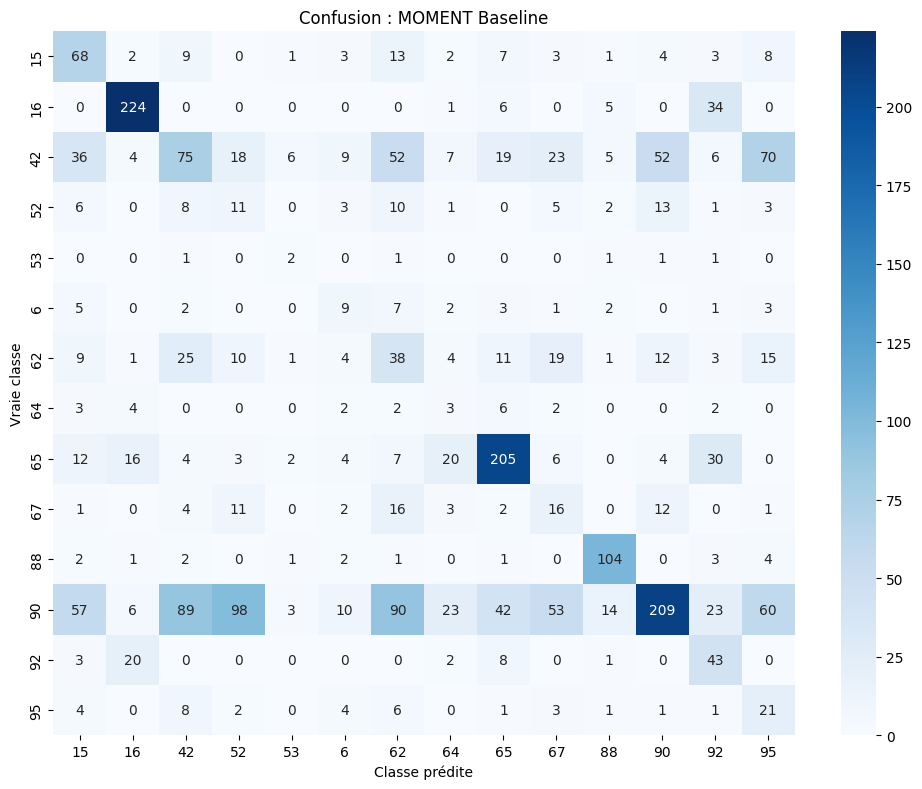

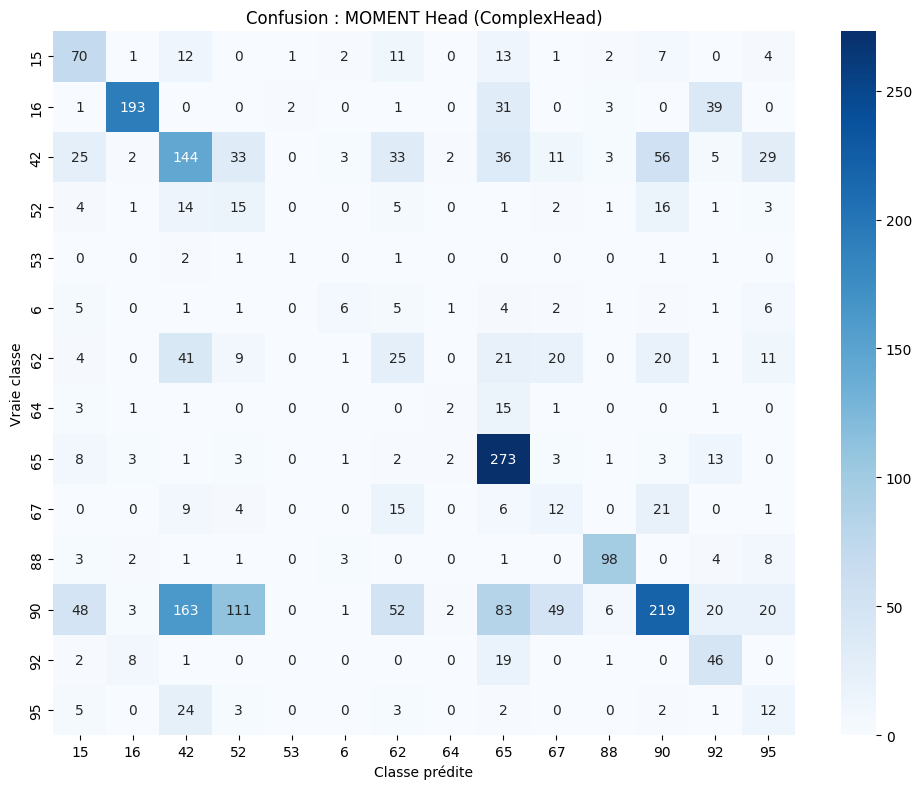

In [33]:
plot_confusion_matrix(model_baseline, nn.Identity(), test_loader, le,
                      title="Confusion : MOMENT Baseline")
plot_confusion_matrix(model_head, nn.Identity(), test_loader, le,
                      title="Confusion : MOMENT Head (ComplexHead)")


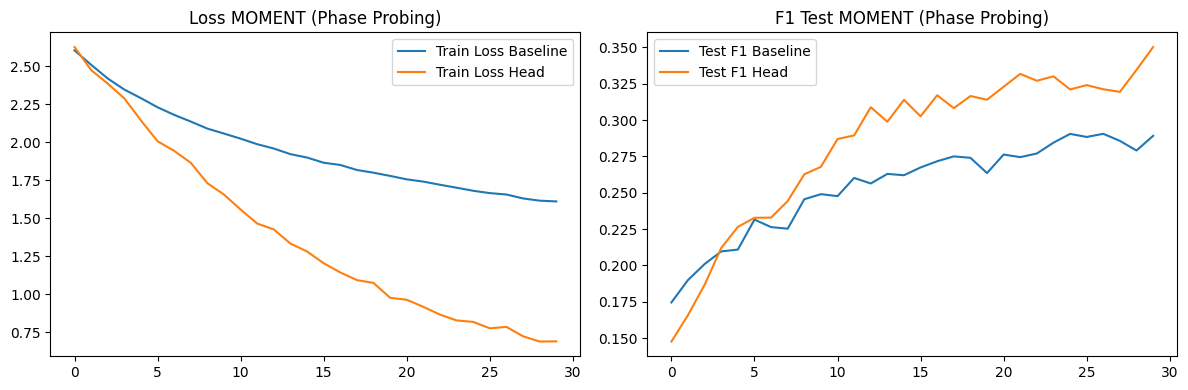

In [34]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_moment["train_loss_base"], label="Train Loss Baseline")
plt.plot(history_moment["train_loss_head"], label="Train Loss Head")
plt.title("Loss MOMENT (Phase Probing)")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_moment["test_f1_base"], label="Test F1 Baseline")
plt.plot(history_moment["test_f1_head"], label="Test F1 Head")
plt.title("F1 Test MOMENT (Phase Probing)")
plt.legend()
plt.tight_layout()
plt.show()


### 4.2 Chronos

Chronos (Amazon) est un modèle T5 pré-entraîné sur des séries temporelles pour le forecasting. On lui ajoute la même `ComplexClassificationHead` et on applique la même stratégie en 3 phases.

In [35]:
CHRONOS_MODEL_ID = "amazon/chronos-t5-small"

class ChronosClassifier(nn.Module):
    """
    Wrapper Chronos avec ComplexClassificationHead externe.
    Même philosophie que MOMENTclassifier dans project.ipynb :
      - Encodeur Chronos T5 figeable
      - Tête complexe externe (avg pooling sur embeddings par canal)
    """
    def __init__(self, model_id, num_classes, num_channels=6, freeze_encoder=True):
        super().__init__()
        print(f"Chargement Chronos : {model_id}...")
        self.pipeline = ChronosPipeline.from_pretrained(
            model_id, device_map=DEVICE, torch_dtype=torch.float32,
        )
        if hasattr(self.pipeline.tokenizer, "boundaries"):
            self.pipeline.tokenizer.boundaries = self.pipeline.tokenizer.boundaries.cpu()

        self.model = self.pipeline.model
        self.num_channels = num_channels

        if freeze_encoder:
            for param in self.model.parameters():
                param.requires_grad = False

        # Dimension cachée Chronos T5
        if hasattr(self.model.config, "model_config") and "d_model" in self.model.config.model_config:
            hidden_dim = self.model.config.model_config["d_model"]
        else:
            hidden_dim = getattr(self.model.config, "d_model", 512)

        self.head = ComplexClassificationHead(
            in_dim=hidden_dim,
            num_classes=num_classes,
            hidden_dim=512,
            dropout=0.4,
        ).to(DEVICE)

    def get_features(self, x):
        """Extrait les features Chronos : avg pooling sur canaux et tokens."""
        B, T, C = x.shape  # [B, T, C] après transpose tslearn
        x_flat = x.permute(0, 2, 1).reshape(B * C, T).cpu()  # [B*C, T]
        embeddings, _ = self.pipeline.embed(x_flat)           # [B*C, tokens, D]
        pooled = embeddings.mean(dim=1).to(DEVICE)            # [B*C, D]
        features = pooled.view(B, C, -1).mean(dim=1)          # [B, D]
        return features

    def forward(self, x):
        features = self.get_features(x)
        return self.head(features)

    def freeze_encoder(self):
        for param in self.model.parameters():
            param.requires_grad = False

    def unfreeze_last_n_layers(self, n=2):
        try:
            layers = list(self.model.encoder.block)
            for layer in layers[-n:]:
                for param in layer.parameters():
                    param.requires_grad = True
        except AttributeError:
            params = list(self.model.named_parameters())
            for _, param in params[-len(params)//4:]:
                param.requires_grad = True

    def unfreeze_encoder(self):
        for param in self.model.parameters():
            param.requires_grad = True


In [36]:
def train_chronos(
    model, train_loader, test_loader, optimizer, n_epoch=10,
    freeze_encoder=True,
):
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    history = {"train_loss": [], "train_acc": [], "test_acc": [], "test_f1": []}

    for epoch in range(n_epoch):
        model.train()
        if freeze_encoder:
            model.model.eval()
            for p in model.model.parameters():
                p.requires_grad = False

        total_loss, preds, labels = 0.0, [], []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            preds.extend(out.argmax(dim=1).cpu().numpy())
            labels.extend(y_batch.cpu().numpy())

        model.eval()
        tp, tl = [], []
        with torch.no_grad():
            for X_t, y_t in test_loader:
                tp.extend(model(X_t.to(DEVICE)).argmax(dim=1).cpu().numpy())
                tl.extend(y_t.cpu().numpy())

        tr_acc  = accuracy_score(labels, preds)
        te_acc  = accuracy_score(tl, tp)
        te_f1   = f1_score(tl, tp, average="macro", zero_division=0)
        tr_loss = total_loss / len(train_loader)

        print(f"Chronos Ep {epoch+1:02d}/{n_epoch} | Loss: {tr_loss:.4f} | "
              f"Train: {tr_acc:.2%} | Test: {te_acc:.2%} | F1: {te_f1:.4f}")

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)
        history["test_f1"].append(te_f1)

    return history

In [37]:
# Instanciation Chronos
chronos_model = ChronosClassifier(
    model_id=CHRONOS_MODEL_ID,
    num_classes=num_classes,
    num_channels=num_channels,
    freeze_encoder=True,
).to(DEVICE)

# ── Phase 1 : Probing ──────────────────────────────────────────
print("=" * 65)
print("PHASE 1 — PROBING CHRONOS (encodeur gelé, 30 epochs)")
print("=" * 65)
opt_chronos_probe = torch.optim.AdamW(chronos_model.head.parameters(), lr=1e-3, weight_decay=1e-2)
history_chronos = train_chronos(
    chronos_model, train_loader, test_loader,
    opt_chronos_probe, n_epoch=30, freeze_encoder=True,
)

# ── Phase 2 : Partial Unfreeze ─────────────────────────────────
print("=" * 65)
print("PHASE 2 — PARTIAL UNFREEZE CHRONOS (2 dernières couches, 15 epochs)")
print("=" * 65)
chronos_model.unfreeze_last_n_layers(n=2)
opt_chronos_partial = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, chronos_model.parameters()), lr=5e-5, weight_decay=1e-2
)
history_chronos_partial = train_chronos(
    chronos_model, train_loader, test_loader,
    opt_chronos_partial, n_epoch=15, freeze_encoder=False,
)

# ── Phase 3 : Full Fine-tuning ─────────────────────────────────
print("=" * 65)
print("PHASE 3 — FULL FINE-TUNING CHRONOS (15 epochs)")
print("=" * 65)
chronos_model.unfreeze_encoder()
opt_chronos_ft = torch.optim.AdamW(chronos_model.parameters(), lr=1e-5, weight_decay=1e-2)
history_chronos_ft = train_chronos(
    chronos_model, train_loader, test_loader,
    opt_chronos_ft, n_epoch=15, freeze_encoder=False,
)

Chargement Chronos : amazon/chronos-t5-small...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


PHASE 1 — PROBING CHRONOS (encodeur gelé, 30 epochs)
Chronos Ep 01/30 | Loss: 2.0045 | Train: 26.11% | Test: 28.10% | F1: 0.3171
Chronos Ep 02/30 | Loss: 1.6148 | Train: 34.32% | Test: 28.91% | F1: 0.3299
Chronos Ep 03/30 | Loss: 1.4113 | Train: 37.01% | Test: 34.91% | F1: 0.3754
Chronos Ep 04/30 | Loss: 1.3464 | Train: 39.32% | Test: 35.08% | F1: 0.3599
Chronos Ep 05/30 | Loss: 1.2010 | Train: 41.32% | Test: 34.02% | F1: 0.3940
Chronos Ep 06/30 | Loss: 1.1704 | Train: 41.44% | Test: 39.82% | F1: 0.4468
Chronos Ep 07/30 | Loss: 1.0832 | Train: 44.73% | Test: 21.61% | F1: 0.3096
Chronos Ep 08/30 | Loss: 1.0764 | Train: 45.22% | Test: 38.28% | F1: 0.4349
Chronos Ep 09/30 | Loss: 0.9578 | Train: 48.23% | Test: 37.23% | F1: 0.3935
Chronos Ep 10/30 | Loss: 0.8680 | Train: 50.79% | Test: 35.60% | F1: 0.3975
Chronos Ep 11/30 | Loss: 0.8459 | Train: 53.07% | Test: 46.96% | F1: 0.4237
Chronos Ep 12/30 | Loss: 0.7727 | Train: 55.84% | Test: 39.74% | F1: 0.4163
Chronos Ep 13/30 | Loss: 0.7282 | T

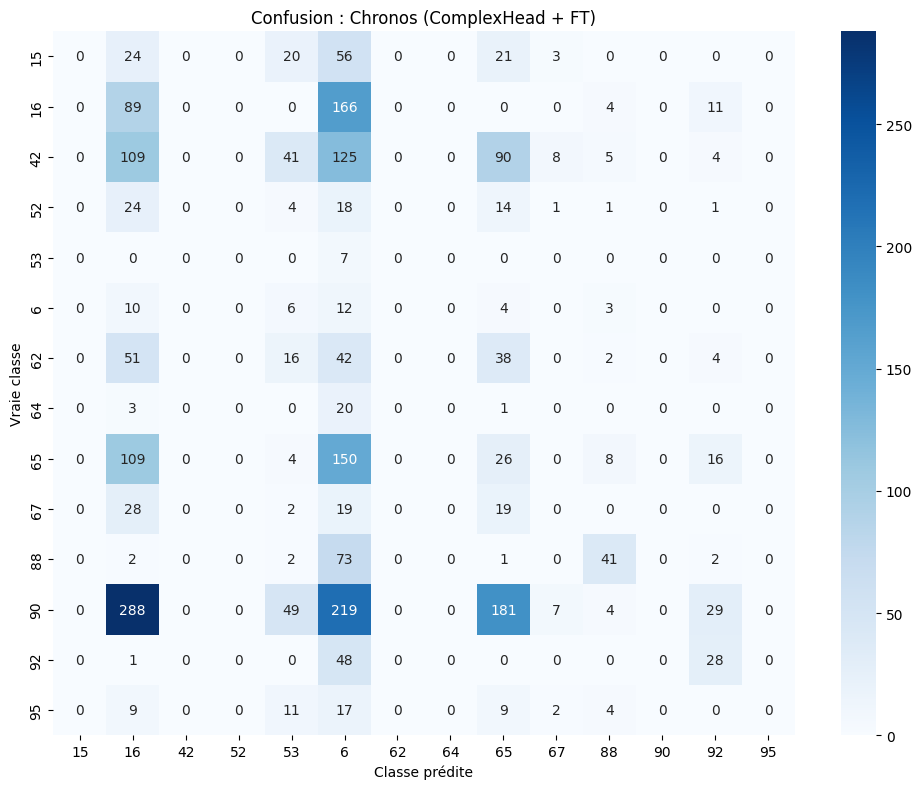

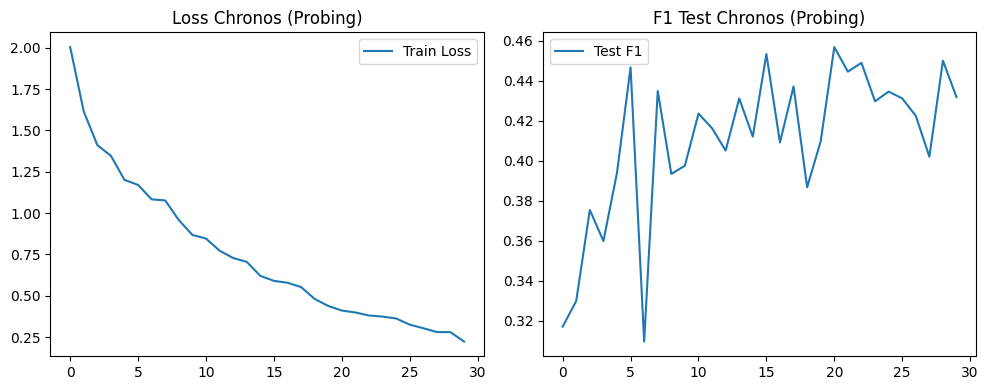

In [38]:
plot_confusion_matrix(chronos_model, nn.Identity(), test_loader, le,
                      title="Confusion : Chronos (ComplexHead + FT)")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_chronos["train_loss"], label="Train Loss")
plt.title("Loss Chronos (Probing)")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_chronos["test_f1"], label="Test F1")
plt.title("F1 Test Chronos (Probing)")
plt.legend()
plt.tight_layout(); plt.show()


In [51]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

def get_probas(model, loader):
    model.eval()
    all_probas, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(DEVICE)
            if X.shape[-1] == 6:  # [B, T, C] → [B, C, T]
                X = X.transpose(1, 2)
            logits = model(X)
            all_probas.append(torch.softmax(logits, dim=1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return np.concatenate(all_probas, axis=0), np.array(all_labels)

def get_probas_chronos(model, loader):
    model.eval()
    all_probas, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(DEVICE)
            if X.shape[1] == 36: X = X.transpose(1, 2)
            logits = model(X)
            all_probas.append(torch.softmax(logits, dim=1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return np.concatenate(all_probas, axis=0), np.array(all_labels)

print("Collecte des probabilités...")
probas_moment,  y_true = get_probas(model_head, test_loader)
probas_chronos, _      = get_probas_chronos(chronos_model, test_loader)

# ── Grid search exhaustif sur w ∈ [0, 1] par pas de 0.01 ──
best_f1, best_w = -1, 0.5
for w in np.linspace(0, 1, 101):
    avg_probs = w * probas_moment + (1 - w) * probas_chronos
    preds = avg_probs.argmax(axis=1)
    f1 = f1_score(y_true, preds, average="macro", zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_w  = w

opt_w = np.array([best_w, 1 - best_w])

print(f"\nPoids optimaux (grid search) :")
print(f"  MOMENT Head : {opt_w[0]:.2f}")
print(f"  Chronos     : {opt_w[1]:.2f}")

# Évaluation finale
avg_probs = opt_w[0] * probas_moment + opt_w[1] * probas_chronos
y_pred    = avg_probs.argmax(axis=1)

f1_ens  = f1_score(y_true, y_pred, average="macro", zero_division=0)
acc_ens = accuracy_score(y_true, y_pred)

f1_moment  = f1_score(y_true, probas_moment.argmax(axis=1),  average="macro", zero_division=0)
acc_moment = accuracy_score(y_true, probas_moment.argmax(axis=1))
f1_chronos  = f1_score(y_true, probas_chronos.argmax(axis=1), average="macro", zero_division=0)
acc_chronos = accuracy_score(y_true, probas_chronos.argmax(axis=1))

print(f"\n{'Model':<30} {'Accuracy':>10} {'F1 (macro)':>12}")
print("-" * 54)
print(f"{'MOMENT Head':<30} {acc_moment:>10.4f} {f1_moment:>12.4f}")
print(f"{'Chronos':<30} {acc_chronos:>10.4f} {f1_chronos:>12.4f}")
print(f"{'Ensemble (poids optimaux)':<30} {acc_ens:>10.4f} {f1_ens:>12.4f}")

Collecte des probabilités...

Poids optimaux (grid search) :
  MOMENT Head : 0.43
  Chronos     : 0.57

Model                            Accuracy   F1 (macro)
------------------------------------------------------
MOMENT Head                        0.4526       0.3623
Chronos                            0.4700       0.4640
Ensemble (poids optimaux)          0.5178       0.4949


## 5. Setting 2 — Pré-entraînement sur forecasting

On pré-entraîne un Transformer sur la tâche de forecasting ETTh1 (dataset Informer), puis on adapte l'encodeur sur LSST.

In [63]:
# Téléchargement direct du dataset ETTh1 (7 variables)
url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df = pd.read_csv(url)
data = df.drop(columns=['date']).values

# Normalisation simple
data = (data - data.mean(axis=0)) / data.std(axis=0)

### 5.1 Pré-entraînement sur ETTh1

Le Transformer apprend à prédire le pas suivant d'une fenêtre de 96 pas sur les 7 variables d'ETTh1 (MSE Loss).

In [64]:
# Variable pour le nombre d'époques
N_EPOCHS_PRETRAIN = 40
BATCH_SIZE = 64
SEQ_LEN = 96  # Longueur de la fenêtre d'entrée
PRED_LEN = 1  # On prédit le point suivant
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [65]:
class InformerDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len

    def __getitem__(self, index):
        s_begin = index
        s_end = s_begin + self.seq_len
        r_begin = s_end
        r_end = r_begin + self.pred_len

        seq_x = self.data[s_begin:s_end]
        seq_y = self.data[r_begin:r_end]
        return seq_x, seq_y

train_ds = InformerDataset(data, SEQ_LEN, PRED_LEN)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

In [66]:
class TransformerForecaster(nn.Module):
    def __init__(self, n_features=7, d_model=128, nhead=8, num_layers=3):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=512, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Tête de forecasting (prédit les variables pour le futur proche)
        self.forecasting_head = nn.Linear(d_model, n_features)

    def forward(self, x):
        # x: [Batch, Seq_Len, Features]
        x = self.input_proj(x)
        x = self.encoder(x)
        # On prédit à partir de la dernière représentation temporelle
        out = self.forecasting_head(x[:, -1, :])
        return out

In [67]:
model = TransformerForecaster().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss() # Utilisation de l'erreur quadratique pour le forecasting

In [68]:
print(f"Début du pré-entraînement sur Informer (ETTh1) pour {N_EPOCHS_PRETRAIN} époques...") #

model.train()
for epoch in range(N_EPOCHS_PRETRAIN): #
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(batch_x)

        # batch_y est [Batch, Pred_Len, Features], on squeeze pour correspondre à outputs
        loss = criterion(outputs, batch_y.squeeze(1))

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Époque [{epoch+1}/{N_EPOCHS_PRETRAIN}] | Train MSE Loss: {epoch_loss/len(train_loader):.6f}")

# Sauvegarde de l'encodeur pour la phase suivante
torch.save(model.encoder.state_dict(), "pretrained_encoder.pt")
print("Pré-entraînement terminé. Encodeur sauvegardé.")

Début du pré-entraînement sur Informer (ETTh1) pour 40 époques...
Époque [1/40] | Train MSE Loss: 0.216369
Époque [2/40] | Train MSE Loss: 0.139752
Époque [3/40] | Train MSE Loss: 0.133339
Époque [4/40] | Train MSE Loss: 0.129546
Époque [5/40] | Train MSE Loss: 0.127064
Époque [6/40] | Train MSE Loss: 0.125359
Époque [7/40] | Train MSE Loss: 0.123354
Époque [8/40] | Train MSE Loss: 0.121711
Époque [9/40] | Train MSE Loss: 0.120772
Époque [10/40] | Train MSE Loss: 0.119347
Époque [11/40] | Train MSE Loss: 0.118812
Époque [12/40] | Train MSE Loss: 0.117035
Époque [13/40] | Train MSE Loss: 0.116261
Époque [14/40] | Train MSE Loss: 0.115935
Époque [15/40] | Train MSE Loss: 0.114471
Époque [16/40] | Train MSE Loss: 0.114315
Époque [17/40] | Train MSE Loss: 0.113153
Époque [18/40] | Train MSE Loss: 0.112905
Époque [19/40] | Train MSE Loss: 0.112278
Époque [20/40] | Train MSE Loss: 0.111620
Époque [21/40] | Train MSE Loss: 0.110872
Époque [22/40] | Train MSE Loss: 0.110367
Époque [23/40] | Tr

### 5.2 Fine-tuning sur LSST

L'encodeur pré-entraîné est chargé et une tête de classification linéaire est ajoutée. On fine-tune l'ensemble sur LSST.

In [69]:
N_EPOCHS_ADAPT = 60
BATCH_SIZE = 32
LR = 1e-5 # plus faible pour le fine-tuning
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [70]:
# Utilisation de tslearn pour charger LSST
#ds = UCR_UEA_datasets()
#X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

# Encodage des labels (pour éviter les erreurs d'index hors limites)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
num_classes = len(le.classes_)

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train_enc, dtype=torch.long)),
    batch_size=BATCH_SIZE, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test_enc, dtype=torch.long)),
    batch_size=BATCH_SIZE
)

In [71]:
class LSSTClassifier(nn.Module):
    def __init__(self, pretrained_encoder_path, d_model=128, num_classes=14):
        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=512, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.encoder.load_state_dict(torch.load(pretrained_encoder_path))

        self.input_proj = nn.Linear(6, d_model)

        self.clf_head = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: [Batch, 36, 6]
        x = self.input_proj(x)
        x = self.encoder(x)
        # Global Average Pooling (moyenne sur la dimension temporelle)
        x = x.mean(dim=1)
        return self.clf_head(x)

In [72]:
model = LSSTClassifier("pretrained_encoder.pt", num_classes=num_classes).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(weights_tensor)

/tmp/ipykernel_545/1159379356.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.encoder.load_state_dict(torch.load(pretrained_encoder_path))


In [73]:
print(f"Début de l'adaptation sur LSST pour {N_EPOCHS_ADAPT} époques...")

for epoch in range(N_EPOCHS_ADAPT):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Évaluation rapide sur le jeu de test [cite: 28]
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(DEVICE)
            outputs = model(batch_x)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.numpy())

    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro')

    print(f"Epoch [{epoch+1}/{N_EPOCHS_ADAPT}] | Loss: {total_loss/len(train_loader):.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")

Début de l'adaptation sur LSST pour 60 époques...
Epoch [1/60] | Loss: 2.6704 | Acc: 0.1444 | F1: 0.0794
Epoch [2/60] | Loss: 2.5559 | Acc: 0.2194 | F1: 0.1222
Epoch [3/60] | Loss: 2.4710 | Acc: 0.2818 | F1: 0.1641
Epoch [4/60] | Loss: 2.3976 | Acc: 0.3252 | F1: 0.1961
Epoch [5/60] | Loss: 2.3205 | Acc: 0.3354 | F1: 0.2010
Epoch [6/60] | Loss: 2.2565 | Acc: 0.3532 | F1: 0.2119
Epoch [7/60] | Loss: 2.2047 | Acc: 0.3552 | F1: 0.2200
Epoch [8/60] | Loss: 2.1544 | Acc: 0.3670 | F1: 0.2342
Epoch [9/60] | Loss: 2.1067 | Acc: 0.3629 | F1: 0.2318
Epoch [10/60] | Loss: 2.0599 | Acc: 0.3775 | F1: 0.2449
Epoch [11/60] | Loss: 2.0236 | Acc: 0.3690 | F1: 0.2547
Epoch [12/60] | Loss: 1.9997 | Acc: 0.3670 | F1: 0.2643
Epoch [13/60] | Loss: 1.9555 | Acc: 0.3735 | F1: 0.2716
Epoch [14/60] | Loss: 1.9375 | Acc: 0.3747 | F1: 0.2757
Epoch [15/60] | Loss: 1.9127 | Acc: 0.3694 | F1: 0.2850
Epoch [16/60] | Loss: 1.8782 | Acc: 0.3719 | F1: 0.2903
Epoch [17/60] | Loss: 1.8586 | Acc: 0.3670 | F1: 0.2927
Epoch [